# English → French Translation with Seq2Seq (PyTorch)

**Workshop notebook** — we will build a neural machine translation model from scratch using **PyTorch**.

### What you will build
A **sequence-to-sequence (Seq2Seq)** model that reads an English sentence and generates a French sentence, token by token:

`I am happy` → `je suis heureux`

### Architecture at a glance
1. **Encoder** — Bidirectional LSTM that reads the English sentence and builds a memory of it
2. **Attention** — at each decoding step, decide *which English words matter right now*
3. **Decoder** — LSTM that writes the French sentence one word at a time

### Learning goals
- Why encoder–decoder models are used for translation
- How **teacher forcing** works during training
- How **Luong (dot-product) attention** is computed
- Why padding must be ignored in the loss (a common accuracy trap)
- How training and inference are different

> **Runtime tip:** enable a GPU (Kaggle / Colab / local CUDA). CPU works, but training will be slower.
---
### Modernized version (Task 1.1)

This version replaces the randomly-initialized embeddings with **pretrained FastText 
(MUSE-aligned) word vectors** for both English and French, and adds **BLEU** and 
**ROUGE** evaluation on top of the original token-accuracy metric. Everything else 
(BiLSTM encoder, Luong attention, LSTM decoder, training loop) is unchanged.

## 1. Setup and configuration

In [1]:
import os
import re
import math
import time
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


In [13]:
import os
import urllib.request
from gensim.models import KeyedVectors

FASTTEXT_URLS = {
    "en": "https://dl.fbaipublicfiles.com/arrival/vectors/wiki.multi.en.vec",
    "fr": "https://dl.fbaipublicfiles.com/arrival/vectors/wiki.multi.fr.vec",
}
EMBED_DIM = 300
CONFIG["embed_dim"] = EMBED_DIM
FREEZE_EMBEDDINGS = False

### Workshop knobs

`WORKSHOP_MODE = True` trains on a subset so a live session can finish in a reasonable time. Set it to `False` when you want the full-data run (closer to the original notebook).


In [2]:
# True  = faster demo (recommended during the workshop)
# False = full dataset, closer to the original TensorFlow notebook
WORKSHOP_MODE = False

CONFIG = {
    "subset_size": 40_000 if WORKSHOP_MODE else None,  # None = use all pairs
    "max_vocab_size": 8_000 if WORKSHOP_MODE else 10_000,
    "max_seq_len": 20 if WORKSHOP_MODE else 40,
    "embed_dim": 256,
    "hidden_dim": 256,          # encoder hidden size (per direction)
    "decoder_hidden": 512,      # 256 * 2 after we merge bidirectional states
    "batch_size": 64,
    "epochs": 8 if WORKSHOP_MODE else 15,
    "learning_rate": 1e-3,
    "dropout": 0.2,
    "patience": 3,              # early stopping
    "grad_clip": 1.0,
    "num_workers": 0,           # keep 0 on Windows / notebooks
}

print("Training config")
for key, value in CONFIG.items():
    print(f"  {key:16s}: {value}")


Training config
  subset_size     : None
  max_vocab_size  : 10000
  max_seq_len     : 40
  embed_dim       : 256
  hidden_dim      : 256
  decoder_hidden  : 512
  batch_size      : 64
  epochs          : 15
  learning_rate   : 0.001
  dropout         : 0.2
  patience        : 3
  grad_clip       : 1.0
  num_workers     : 0


## 2. Load the dataset

In [3]:
def _read_csv_pairs(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    # Kaggle file uses English / French column names
    cols = {c.lower().strip(): c for c in df.columns}
    eng_col = cols.get("english") or cols.get("en") or list(df.columns)[0]
    fr_col = cols.get("french") or cols.get("fr") or list(df.columns)[1]
    out = df[[eng_col, fr_col]].copy()
    out.columns = ["English", "French"]
    return out.dropna()


def _read_tsv_pairs(path: str) -> pd.DataFrame:
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) >= 2:
                rows.append((parts[0], parts[1]))
    return pd.DataFrame(rows, columns=["English", "French"])


def _download_anki_fra_eng(dest_dir: Path) -> Path:
    """Official PyTorch tutorial data: English \\t French pairs."""
    import urllib.request
    import zipfile

    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "anki_data.zip"
    txt_path = dest_dir / "eng-fra.txt"
    if txt_path.exists():
        return txt_path

    url = "https://download.pytorch.org/tutorial/data.zip"
    print(f"Downloading translation pairs from {url} ...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        # archive contains data/eng-fra.txt
        for name in zf.namelist():
            if name.endswith("eng-fra.txt"):
                zf.extract(name, dest_dir)
                extracted = dest_dir / name
                extracted.replace(txt_path)
                break
    print(f"Saved to {txt_path}")
    return txt_path


def load_translation_dataframe() -> pd.DataFrame:
    candidates = [
        "/kaggle/input/language-translation-englishfrench/eng_-french.csv",
        "eng_-french.csv",
        str(Path.home() / "Downloads" / "eng_-french.csv"),
        str(Path.cwd() / "eng_-french.csv"),
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f"Loaded local CSV: {path}")
            return _read_csv_pairs(path)

    txt_path = _download_anki_fra_eng(Path.cwd() / "data")
    print(f"Loaded Anki / Tatoeba file: {txt_path}")
    return _read_tsv_pairs(txt_path)


df = load_translation_dataframe()
df = df[df["English"].astype(str).str.strip().ne("") & df["French"].astype(str).str.strip().ne("")]
df = df.drop_duplicates(subset=["English", "French"]).reset_index(drop=True)

if CONFIG["subset_size"] is not None and len(df) > CONFIG["subset_size"]:
    df = df.sample(n=CONFIG["subset_size"], random_state=SEED).reset_index(drop=True)
    print(f"Workshop subset: using {len(df):,} sentence pairs")
else:
    print(f"Using the full cleaned set: {len(df):,} sentence pairs")

df.head(8)


Saved to /kaggle/working/data/eng-fra.txt
Loaded Anki / Tatoeba file: /kaggle/working/data/eng-fra.txt
Using the full cleaned set: 135,842 sentence pairs


,English,French
0,Go.,Va !
1,Run!,Cours !
2,Run!,Courez !
3,Wow!,Ça alors !
4,Fire!,Au feu !
5,Help!,À l'aide !
6,Jump.,Saute.
7,Stop!,Ça suffit !


### Quick look at the data

Before cleaning, check length and a few raw examples. Most everyday sentences in this corpus are short — that is why a max length of 20 is enough in workshop mode.


Pairs: 135,842

Random examples:
  EN: The wind was so strong, we were nearly blown off the road.
  FR: Le vent était tellement fort que nous avons presque été poussés en dehors de la route.

  EN: You can never be happy if you feel envious of other people.
  FR: Tu ne peux jamais être heureux si tu te sens envieux à l'égard d'autrui.

  EN: Let's reconsider the problem.
  FR: Reconsidérons le problème !

  EN: Stop it, please.
  FR: Cessez, je vous prie !

  EN: You are the one.
  FR: Vous êtes celui-là.

English words  — mean 6.2, max 47
French words   — mean 6.7, max 54


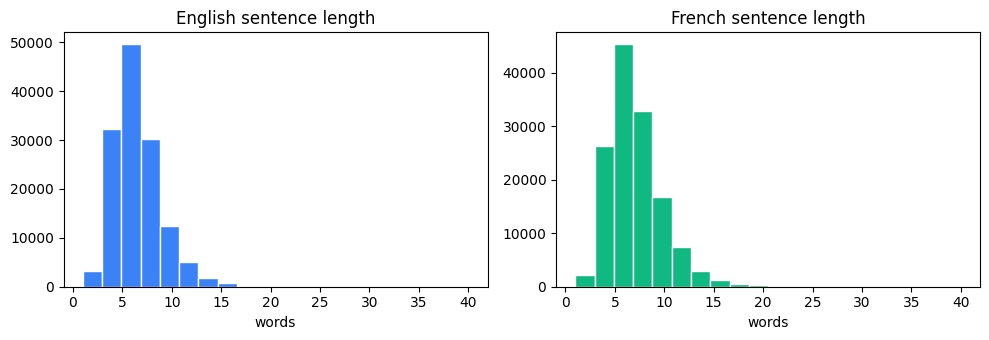

In [4]:
print(f"Pairs: {len(df):,}")
print("\nRandom examples:")
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f"  EN: {row['English']}")
    print(f"  FR: {row['French']}\n")

eng_lens = df["English"].astype(str).str.split().str.len()
fr_lens = df["French"].astype(str).str.split().str.len()
print(f"English words  — mean {eng_lens.mean():.1f}, max {eng_lens.max()}")
print(f"French words   — mean {fr_lens.mean():.1f}, max {fr_lens.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(eng_lens.clip(upper=40), bins=20, color="#3b82f6", edgecolor="white")
axes[0].set_title("English sentence length")
axes[0].set_xlabel("words")
axes[1].hist(fr_lens.clip(upper=40), bins=20, color="#10b981", edgecolor="white")
axes[1].set_title("French sentence length")
axes[1].set_xlabel("words")
plt.tight_layout()
plt.show()


## 3. Text cleaning

Neural models need consistent input. We:

1. Lowercase everything (`Hi.` and `hi` should be the same token)
2. Expand a few common contractions (`don't` → `do not`)
3. Keep letters (and French accents) and spaces, drop the rest
4. Collapse repeated spaces

We do **not** add `<start>` / `<end>` here. Those special tokens are added later, when we convert text to IDs. That is cleaner than baking them into the raw strings.


In [5]:
EN_CONTRACTIONS = {
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "he'll": "he will", "she'll": "she will",
    "we'll": "we will", "they'll": "they will",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "haven't": "have not",
    "hasn't": "has not", "hadn't": "had not", "let's": "let us",
}

FR_CONTRACTIONS = {
    "c'est": "ce est", "j'ai": "je ai", "n'est": "ne est",
    "qu'est": "que est", "d'accord": "de accord", "l'est": "le est",
}

# Letters we keep for French (accents + oe ligature)
FR_KEEP = r"a-zàâäçéèêëîïôùûüœÿ\s"


def _expand(text: str, table: dict) -> str:
    for src_tok, dst_tok in table.items():
        text = re.sub(rf"\b{re.escape(src_tok)}\b", dst_tok, text)
    return text


def clean_english(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, EN_CONTRACTIONS)
    text = re.sub(r"[^a-z\s]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def clean_french(text: str) -> str:
    text = str(text).lower().strip()
    text = _expand(text, FR_CONTRACTIONS)
    text = re.sub(rf"[^{FR_KEEP}]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


df["English"] = df["English"].map(clean_english)
df["French"] = df["French"].map(clean_french)
df = df[(df["English"].str.len() > 0) & (df["French"].str.len() > 0)].reset_index(drop=True)

print("After cleaning:")
for _, row in df.head(5).iterrows():
    print(f"  {row['English']:30s}  →  {row['French']}")


After cleaning:
  go                              →  va
  run                             →  cours
  run                             →  courez
  wow                             →  ça alors
  fire                            →  au feu


## 4. Train / validation / test split

We hold out **10% for test** (final numbers) and **10% of the remainder for validation** (early stopping). The vocabulary is built from the **training set only**, so the model never “sees” test words while building its dictionary.


In [6]:
train_df, test_df = train_test_split(df, test_size=0.10, random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.10, random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Valid: {len(val_df):,}")
print(f"Test : {len(test_df):,}")


Train: 110,031
Valid: 12,226
Test : 13,585


## 5. Vocabulary and numericalization

A neural net cannot read strings. We map every word to an integer ID.

| Token | ID | Role |
|---|---|---|
| `<pad>` | 0 | Fills shorter sentences so a batch has one rectangular tensor |
| `<unk>` | 1 | Words that did not make the vocabulary cutoff |
| `<start>` | 2 | Tells the decoder “begin generating” |
| `<end>` | 3 | Tells the decoder “the sentence is finished” |

**Why `<start>` and `<end>`?**  
The decoder is a language model conditioned on the English sentence. It needs a first input token (`<start>`) and a stop signal (`<end>`). Without `<end>`, it would never know when to stop.


In [7]:
class Vocabulary:
    """Word-level vocabulary with reserved special tokens."""

    PAD = "<pad>"
    UNK = "<unk>"
    SOS = "<start>"
    EOS = "<end>"

    def __init__(self, max_size: int = 10_000):
        self.max_size = max_size
        self.word2idx = {self.PAD: 0, self.UNK: 1, self.SOS: 2, self.EOS: 3}
        self.idx2word = {idx: word for word, idx in self.word2idx.items()}

    def build(self, sentences):
        counts = Counter()
        for sentence in sentences:
            counts.update(sentence.split())

        # Keep the most frequent words; reserve 4 slots for special tokens
        for word, _ in counts.most_common(self.max_size - 4):
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word
        return self

    def encode(self, sentence: str, max_len: int, add_special: bool = False):
        tokens = sentence.split()
        if add_special:
            tokens = [self.SOS] + tokens + [self.EOS]
        ids = [self.word2idx.get(tok, self.word2idx[self.UNK]) for tok in tokens]
        ids = ids[:max_len]
        length = len(ids)
        ids = ids + [self.word2idx[self.PAD]] * (max_len - length)
        return ids, length

    def decode(self, ids, skip_special: bool = True):
        special = {self.PAD, self.UNK, self.SOS, self.EOS} if skip_special else set()
        words = []
        for idx in ids:
            word = self.idx2word.get(int(idx), self.UNK)
            if word == self.EOS:
                break
            if word in special:
                continue
            words.append(word)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

    @property
    def pad_idx(self):
        return self.word2idx[self.PAD]

    @property
    def sos_idx(self):
        return self.word2idx[self.SOS]

    @property
    def eos_idx(self):
        return self.word2idx[self.EOS]

    @property
    def unk_idx(self):
        return self.word2idx[self.UNK]


src_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["English"])
tgt_vocab = Vocabulary(CONFIG["max_vocab_size"]).build(train_df["French"])

print(f"English vocab size: {len(src_vocab):,}")
print(f"French vocab size : {len(tgt_vocab):,}")
print("Sample English IDs:", list(src_vocab.word2idx.items())[:8])
print("Sample French IDs :", list(tgt_vocab.word2idx.items())[:8])


English vocab size: 10,000
French vocab size : 10,000
Sample English IDs: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('i', 4), ('you', 5), ('to', 6), ('the', 7)]
Sample French IDs : [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('je', 4), ('de', 5), ('pas', 6), ('vous', 7)]


## 5.5 Pretrained word embeddings (FastText)

We initialize the embedding layers with **FastText (MUSE-aligned)** vectors instead of 
random weights, so the model starts with real word meaning instead of learning it from 
scratch. English and French vectors share the same 300-d space, giving the model a 
cross-lingual head start.

In [14]:
import os
import urllib.request
from gensim.models import KeyedVectors

FASTTEXT_URLS = {
    "en": "https://dl.fbaipublicfiles.com/arrival/vectors/wiki.multi.en.vec",
    "fr": "https://dl.fbaipublicfiles.com/arrival/vectors/wiki.multi.fr.vec",
}
EMBED_DIM = 300
CONFIG["embed_dim"] = EMBED_DIM
FREEZE_EMBEDDINGS = False

VEC_DIR = Path("/kaggle/working/fasttext")
VEC_DIR.mkdir(parents=True, exist_ok=True)


def download_vectors(lang: str) -> Path:
    out_path = VEC_DIR / f"wiki.multi.{lang}.vec"
    if not out_path.exists():
        print(f"Downloading {lang.upper()} FastText (MUSE-aligned) vectors ...")
        urllib.request.urlretrieve(FASTTEXT_URLS[lang], out_path)
    else:
        print(f"{lang.upper()} vectors already downloaded, reusing cache.")
    return out_path


def build_embedding_matrix(vec_path: Path, vocab: "Vocabulary", embed_dim: int = EMBED_DIM):
    kv = KeyedVectors.load_word2vec_format(str(vec_path), binary=False)
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(scale=0.1, size=(len(vocab), embed_dim)).astype(np.float32)
    matrix[vocab.pad_idx] = np.zeros(embed_dim, dtype=np.float32)

    found = 0
    for word, idx in vocab.word2idx.items():
        if word in kv:
            matrix[idx] = kv[word]
            found += 1
    coverage = found / len(vocab)
    print(f"  matched {found:,}/{len(vocab):,} vocab words in FastText  ({coverage:.1%} coverage)")
    return torch.tensor(matrix, dtype=torch.float32)


en_vec_path = download_vectors("en")
fr_vec_path = download_vectors("fr")

print("\nBuilding embedding matrix for English (source) vocabulary...")
src_embedding_matrix = build_embedding_matrix(en_vec_path, src_vocab)
print("\nBuilding embedding matrix for French (target) vocabulary...")
tgt_embedding_matrix = build_embedding_matrix(fr_vec_path, tgt_vocab)


Building embedding matrix for English (source) vocabulary...
  matched 9,857/10,000 vocab words in FastText  (98.6% coverage)

Building embedding matrix for French (target) vocabulary...
  matched 9,277/10,000 vocab words in FastText  (92.8% coverage)


## 6. Dataset and DataLoader

Each training example is three tensors:

- `src` — English IDs, shape `(max_len,)`
- `tgt_in` — French IDs **with `<start>`**, used as decoder input
- `tgt_out` — French IDs **shifted left** (the next word the decoder should predict), ending with `<end>`

Example for `bonjour` (simplified):

```
tgt_in  = [<start>, bonjour, <end>, <pad>, ...]
tgt_out = [bonjour, <end>,   <pad>, <pad>, ...]
```

The model sees `tgt_in[t]` and must predict `tgt_out[t]`. That is **teacher forcing**: during training we feed the *correct* previous word, not the model’s own prediction. Training becomes much more stable.

> The original Keras notebook did the same thing by passing the full French sequence as decoder input and `french[:, 1:]` as the target.


In [15]:
class TranslationDataset(Dataset):
    def __init__(self, frame, src_vocab, tgt_vocab, max_len):
        self.src_texts = frame["English"].tolist()
        self.tgt_texts = frame["French"].tolist()
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        src_ids, src_len = self.src_vocab.encode(
            self.src_texts[idx], self.max_len, add_special=False
        )
        tgt_ids, tgt_len = self.tgt_vocab.encode(
            self.tgt_texts[idx], self.max_len, add_special=True
        )
        # Decoder input = everything except the last token
        # Decoder target = everything except <start>
        tgt_in = tgt_ids[:-1]
        tgt_out = tgt_ids[1:]
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "src_len": torch.tensor(src_len, dtype=torch.long),
            "tgt_in": torch.tensor(tgt_in, dtype=torch.long),
            "tgt_out": torch.tensor(tgt_out, dtype=torch.long),
            "src_text": self.src_texts[idx],
            "tgt_text": self.tgt_texts[idx],
        }


def make_loader(frame, shuffle):
    dataset = TranslationDataset(frame, src_vocab, tgt_vocab, CONFIG["max_seq_len"])
    return DataLoader(
        dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=shuffle,
        num_workers=CONFIG["num_workers"],
        drop_last=False,
    )


train_loader = make_loader(train_df, shuffle=True)
val_loader = make_loader(val_df, shuffle=False)
test_loader = make_loader(test_df, shuffle=False)

batch = next(iter(train_loader))
print("Batch tensor shapes")
print(f"  src     {tuple(batch['src'].shape)}     # (batch, src_len)")
print(f"  tgt_in  {tuple(batch['tgt_in'].shape)}  # (batch, tgt_len - 1)")
print(f"  tgt_out {tuple(batch['tgt_out'].shape)} # (batch, tgt_len - 1)")
print()
print("Text :", batch["src_text"][0], "→", batch["tgt_text"][0])
print("src  :", batch["src"][0].tolist()[:12])
print("in   :", batch["tgt_in"][0].tolist()[:12])
print("out  :", batch["tgt_out"][0].tolist()[:12])


Batch tensor shapes
  src     (64, 40)     # (batch, src_len)
  tgt_in  (64, 39)  # (batch, tgt_len - 1)
  tgt_out (64, 39) # (batch, tgt_len - 1)

Text : a bill came along with the package → une facture accompagnait le paquet
src  : [9, 995, 231, 579, 38, 7, 2498, 0, 0, 0, 0, 0]
in   : [2, 26, 3142, 1, 14, 2556, 3, 0, 0, 0, 0, 0]
out  : [26, 3142, 1, 14, 2556, 3, 0, 0, 0, 0, 0, 0]


## 7. Model: Seq2Seq with attention

### 7.1 Why encoder–decoder?

Translation is a **sequence-to-sequence** problem: the input and output have different lengths and different word orders.

```
English (source)          French (target)
I     love   cats    →    j'   aime   les   chats
```

A single LSTM that reads English and immediately writes French would struggle, because it would have to start generating before it has seen the full source sentence. The encoder–decoder split fixes that:

- The **encoder** reads the *entire* English sentence first
- The **decoder** then writes French, looking back at the encoder memory

### 7.2 Bidirectional LSTM encoder

A normal LSTM reads left → right. A **bidirectional** LSTM also reads right → left, then concatenates both hidden states.

That helps because the meaning of a word often depends on both sides:

`bank` in `river bank` vs `bank account`

Encoder hidden size is `256` per direction, so the concatenated state is `512`. The decoder LSTM therefore uses hidden size `512` so it can be initialized from those states.

### 7.3 Luong / dot-product attention

The original “bottleneck” Seq2Seq compressed the whole sentence into one vector. Attention lets the decoder **look at every encoder step** and pick what is relevant.

For one decoder step, with query \(q\) (decoder hidden) and encoder memory \(K\) (all encoder outputs):

$$
\text{scores} = q \cdot K^\top
$$

$$
\alpha = \mathrm{softmax}(\text{scores})
$$

$$
\text{context} = \alpha \cdot V
$$

Intuition: \(\alpha\) is a probability distribution over English words. The context vector is a weighted summary of the source sentence for *this* French word.

We then concatenate `[decoder_output ; context]` and project to the French vocabulary.

This is the same idea as the custom `AttentionLayer` in the TensorFlow notebook, with one important upgrade: **we mask pad positions** so the model cannot attend to padding.


In [17]:
class Encoder(nn.Module):
    """Bidirectional LSTM encoder.

    Input : (batch, src_len) token IDs
    Output: encoder_outputs (batch, src_len, 2*hidden)
            hidden, cell    (1, batch, 2*hidden)  — merged directions
    """

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        if embedding_matrix is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embedding_matrix, padding_idx=pad_idx, freeze=freeze_embeddings
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat([hidden[0], hidden[1]], dim=-1).unsqueeze(0)
        cell = torch.cat([cell[0], cell[1]], dim=-1).unsqueeze(0)
        return outputs, hidden, cell


class LuongAttention(nn.Module):
    """Dot-product attention with optional padding mask."""

    def forward(self, decoder_outputs, encoder_outputs, src_mask=None):
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))
        if src_mask is not None:
            scores = scores.masked_fill(~src_mask.unsqueeze(1), -1e9)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, encoder_outputs)
        return context, weights


class Decoder(nn.Module):
    """LSTM decoder + attention + vocab projection."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, pad_idx, dropout=0.2,
                 embedding_matrix=None, freeze_embeddings=False):
        super().__init__()
        if embedding_matrix is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embedding_matrix, padding_idx=pad_idx, freeze=freeze_embeddings
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=1, batch_first=True)
        self.attention = LuongAttention()
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt_in, hidden, cell, encoder_outputs, src_mask=None):
        embedded = self.dropout(self.embedding(tgt_in))
        dec_out, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        context, attn = self.attention(dec_out, encoder_outputs, src_mask)
        combined = torch.cat([dec_out, context], dim=-1)
        logits = self.fc(combined)
        return logits, hidden, cell, attn


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def create_src_mask(self, src):
        return src != self.pad_idx

    def forward(self, src, tgt_in):
        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.create_src_mask(src)
        logits, _, _, attn = self.decoder(
            tgt_in, hidden, cell, encoder_outputs, src_mask
        )
        return logits, attn

In [18]:
encoder = Encoder(
    vocab_size=len(src_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["hidden_dim"],
    pad_idx=src_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    embedding_matrix = src_embedding_matrix,
    freeze_embeddings = FREEZE_EMBEDDINGS,
)
decoder = Decoder(
    vocab_size=len(tgt_vocab),
    embed_dim=CONFIG["embed_dim"],
    hidden_dim=CONFIG["decoder_hidden"],
    pad_idx=tgt_vocab.pad_idx,
    dropout=CONFIG["dropout"],
    embedding_matrix = tgt_embedding_matrix,
    freeze_embeddings = FREEZE_EMBEDDINGS,
)
model = Seq2Seq(encoder, decoder, pad_idx=src_vocab.pad_idx).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(10000, 300, padding_idx=0)
    (lstm): LSTM(300, 256, batch_first=True, bidirectional=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 300, padding_idx=0)
    (lstm): LSTM(300, 512, batch_first=True)
    (attention): LuongAttention()
    (fc): Linear(in_features=1024, out_features=10000, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

Trainable parameters: 19,059,856


## 8. Loss, metrics, and the padding trap

We use **cross-entropy** over the French vocabulary.

**Important workshop point:** the original Keras notebook reported ~96% accuracy. A large part of that number came from **padding tokens**. If 70% of a batch is `<pad>` and the model learns to predict pad after `<end>`, accuracy looks excellent even when the real words are mediocre.

In PyTorch we pass `ignore_index=PAD` so pad positions do **not** contribute to the loss or to our token accuracy. The number will look lower — and more honest.


In [19]:
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab.pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)


def token_accuracy(logits, targets, pad_idx):
    """Accuracy on non-pad tokens only."""
    preds = logits.argmax(dim=-1)
    mask = targets != pad_idx
    if mask.sum() == 0:
        return 0.0
    return (preds[mask] == targets[mask]).float().mean().item()


def run_epoch(loader, train: bool):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            src = batch["src"].to(device)
            tgt_in = batch["tgt_in"].to(device)
            tgt_out = batch["tgt_out"].to(device)

            logits, _ = model(src, tgt_in)  # (B, T, V)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
                optimizer.step()

            total_loss += loss.item()
            total_acc += token_accuracy(logits, tgt_out, tgt_vocab.pad_idx)
            n_batches += 1

    return total_loss / max(n_batches, 1), total_acc / max(n_batches, 1)


## 9. Training loop

Each epoch:

1. Encode English
2. Decode the full French sequence in one shot (teacher forcing)
3. Compare predicted tokens with `tgt_out`
4. Backpropagate, clip gradients, step the optimizer

**Early stopping** watches validation loss. If it does not improve for `patience` epochs, we restore the best weights and stop. That is the PyTorch equivalent of Keras `EarlyStopping(restore_best_weights=True)`.

**Gradient clipping** (`max_norm=1.0`) keeps LSTM training from exploding — a classic RNN issue.


In [20]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = math.inf
best_state = None
stale = 0
t0 = time.time()

print(f"{'epoch':>6}  {'train_loss':>11}  {'val_loss':>9}  {'train_acc':>10}  {'val_acc':>8}  {'time':>6}")
print("-" * 64)

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    elapsed = time.time() - epoch_start
    print(
        f"{epoch:6d}  {train_loss:11.4f}  {val_loss:9.4f}  "
        f"{train_acc:10.3f}  {val_acc:8.3f}  {elapsed:5.0f}s"
    )

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1
        if stale >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch} (best val loss = {best_val:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f"\nFinished in {(time.time() - t0) / 60:.1f} min. Best val loss: {best_val:.4f}")


 epoch   train_loss   val_loss   train_acc   val_acc    time
----------------------------------------------------------------
     1       2.9248     1.7204       0.491     0.647    124s
     2       1.3745     1.3109       0.694     0.710    124s
     3       0.9952     1.1939       0.754     0.730    124s
     4       0.8002     1.1594       0.789     0.738    124s
     5       0.6743     1.1452       0.814     0.744    124s
     6       0.5848     1.1478       0.833     0.748    124s
     7       0.5173     1.1652       0.849     0.751    124s
     8       0.3901     1.1316       0.879     0.757    124s
     9       0.3406     1.1519       0.892     0.756    124s
    10       0.3136     1.1674       0.899     0.757    124s
    11       0.2590     1.1688       0.914     0.758    124s
Early stopping at epoch 11 (best val loss = 1.1316)

Finished in 22.8 min. Best val loss: 1.1316


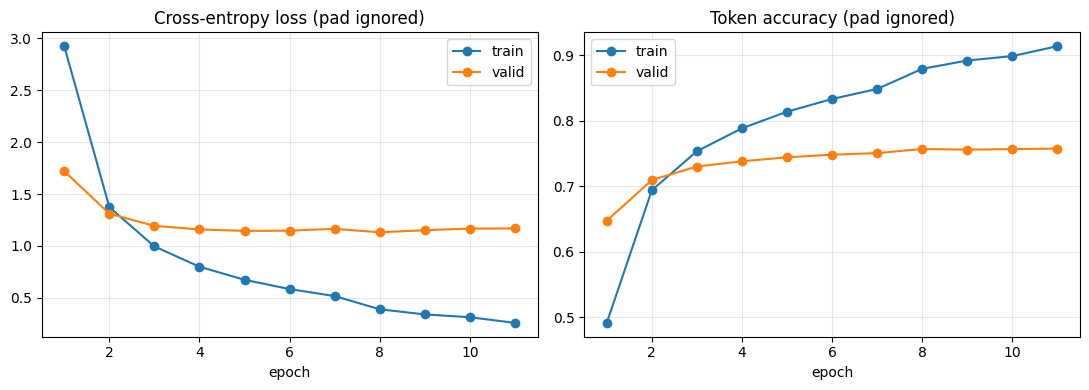

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_x = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_x, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_x, history["val_loss"], marker="o", label="valid")
axes[0].set_title("Cross-entropy loss (pad ignored)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_x, history["val_acc"], marker="o", label="valid")
axes[1].set_title("Token accuracy (pad ignored)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluation on the test set

Same metric as validation: loss and token accuracy, **padding ignored**.


In [22]:
test_loss, test_acc = run_epoch(test_loader, train=False)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.3f}   ← non-pad French tokens only")


Test loss:     1.1196
Test accuracy: 0.759   ← non-pad French tokens only


## 11. Inference: translating a new sentence

Training used teacher forcing (the correct previous French word).  
**Inference cannot do that** — we do not have the French sentence yet.

Greedy decoding:

1. Encode the English sentence once
2. Feed `<start>` to the decoder
3. Pick the most likely next word (`argmax`)
4. Feed that word back in
5. Repeat until `<end>` or `max_len`

This is slower than training (one token per step) but it is how the model is actually used.

We also return the attention matrix so we can draw a heatmap: rows = generated French words, columns = English words.


In [23]:
@torch.no_grad()
def translate_sentence(sentence: str, max_len: int = None, return_attention: bool = False):
    """Greedy decode one English sentence → French string."""
    model.eval()
    max_len = max_len or CONFIG["max_seq_len"]

    cleaned = clean_english(sentence)
    src_ids, src_len = src_vocab.encode(cleaned, CONFIG["max_seq_len"], add_special=False)
    src = torch.tensor(src_ids, dtype=torch.long, device=device).unsqueeze(0)  # (1, S)

    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.create_src_mask(src)

    token = torch.tensor([[tgt_vocab.sos_idx]], device=device)  # (1, 1)
    output_ids = []
    attn_steps = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(
            token, hidden, cell, encoder_outputs, src_mask
        )
        next_id = int(logits[0, -1].argmax())
        attn_steps.append(attn[0, 0, :src_len].detach().cpu())
        if next_id == tgt_vocab.eos_idx:
            break
        output_ids.append(next_id)
        token = torch.tensor([[next_id]], device=device)

    text = tgt_vocab.decode(output_ids)
    if return_attention:
        attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros(1, src_len)
        src_tokens = cleaned.split()[:src_len]
        tgt_tokens = text.split()
        return text, src_tokens, tgt_tokens, attn_mat
    return text


def plot_attention(src_tokens, tgt_tokens, attn_mat, title="Attention"):
    if len(src_tokens) == 0 or len(tgt_tokens) == 0:
        print("Nothing to plot (empty translation).")
        return
    # attn_mat may have one extra row if we stopped on <end>
    rows = min(len(tgt_tokens), attn_mat.size(0))
    mat = attn_mat[:rows, :len(src_tokens)].numpy()

    fig, ax = plt.subplots(figsize=(max(4, 0.55 * len(src_tokens) + 2), max(3, 0.45 * rows + 1.5)))
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(src_tokens)))
    ax.set_xticklabels(src_tokens, rotation=45, ha="right")
    ax.set_yticks(range(rows))
    ax.set_yticklabels(tgt_tokens[:rows])
    ax.set_xlabel("English (source)")
    ax.set_ylabel("French (generated)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


print(translate_sentence("I am very happy today"))
print(translate_sentence("Where is the parking?"))


je suis très heureux aujourd hui
où est le


## 12. Qualitative results

Random test sentences: reference vs model output. Short, frequent phrases are usually better than long / rare ones — that is expected for a from-scratch LSTM on a limited vocabulary.


In [24]:
def show_translations(n=10, seed=0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(test_df)), k=min(n, len(test_df)))
    rows = []
    for i in indices:
        eng = test_df.loc[i, "English"]
        ref = test_df.loc[i, "French"]
        pred = translate_sentence(eng)
        rows.append({"English": eng, "Reference (FR)": ref, "Predicted (FR)": pred})
    return pd.DataFrame(rows)


translations_df = show_translations(n=12, seed=7)
pd.set_option("display.max_colwidth", 80)
translations_df


,English,Reference (FR),Predicted (FR)
0,he made up a story about the dog,il inventa une histoire au sujet du chien,il a inventé une histoire au sujet du chien
1,i argued with him about it,je me suis disputé avec lui à ce propos,je me suis avec lui
2,there is nothing like cold beer on a hot day,il n y a rien de tel qu une bière fraîche un jour de canicule,il n y a rien de frais d eau sur un jour chaud
3,i know the reason but i cannot tell you,je connais la raison mais je ne peux pas vous la dire,je sais la raison mais je ne peux pas vous le dire
4,my children do not listen to me,mes enfants ne m écoutent pas,mes enfants m adorent
5,i got dumped,je ai été larguée,on m a largué
6,can you determine what happened,peux tu déterminer ce qui s est passé,peux tu déterminer ce qui s est passé
7,i wish him the very best in his future endeavors,je lui souhaite le meilleur dans ses futures entreprises,je lui souhaite le meilleur que le futur d ses futures entreprises
8,tom is always watching tv,tom regarde toujours la télévision,tom regarde toujours la télévision
9,i will leave it up to you,je vous laisse la décision,je te laisserai la décision


## 10.5 Evaluation metrics: BLEU and ROUGE

Token accuracy only tells us how often the model predicts the exact next gold token 
during teacher forcing — it says nothing about whether a freely generated translation 
is actually good. We now evaluate full generated sentences against references using:

**BLEU** — n-gram precision (1 to 4-gram) with a brevity penalty. The standard MT metric.

**ROUGE** — recall-oriented overlap (ROUGE-1/2 for unigrams/bigrams, ROUGE-L for longest 
common subsequence). A useful complement to BLEU's precision focus.

We evaluate on a random sample of the test set (greedy decoding one sentence at a time 
is slow over the full ~13.6k set).

In [25]:
!pip install -q rouge-score

from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer

N_EVAL_SAMPLES = 1000  # subset for speed; set to len(test_df) for the full test set


@torch.no_grad()
def generate_for_bleu_rouge(frame, n_samples, seed=SEED):
    model.eval()
    subset = frame.sample(min(n_samples, len(frame)), random_state=seed)
    references, hypotheses = [], []
    for _, row in subset.iterrows():
        pred = translate_sentence(row["English"])
        references.append(row["French"].split())
        hypotheses.append(pred.split())
    return references, hypotheses


references, hypotheses = generate_for_bleu_rouge(test_df, N_EVAL_SAMPLES)

smoothie = SmoothingFunction().method4
bleu_score = corpus_bleu([[ref] for ref in references], hypotheses, smoothing_function=smoothie)

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)
rouge1_scores, rouge2_scores, rougeL_scores = [], [], []
for ref, hyp in zip(references, hypotheses):
    scores = scorer.score(" ".join(ref), " ".join(hyp))
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

print(f"Evaluated on {len(references)} test sentences\n")
print(f"BLEU     : {bleu_score * 100:.2f}")
print(f"ROUGE-1  : {np.mean(rouge1_scores):.4f}")
print(f"ROUGE-2  : {np.mean(rouge2_scores):.4f}")
print(f"ROUGE-L  : {np.mean(rougeL_scores):.4f}")

Evaluated on 1000 test sentences

BLEU     : 43.94
ROUGE-1  : 0.6912
ROUGE-2  : 0.5096
ROUGE-L  : 0.6819


### Attention heatmap

Bright cells mean: “when I generated this French word, I was looking at that English word.” For a well-trained model you often see a roughly diagonal pattern, with extra mass on words like *not* / *ne* that flip meaning.


EN : it is pitch black outside
FR : il fait noir comme dans un four dehors


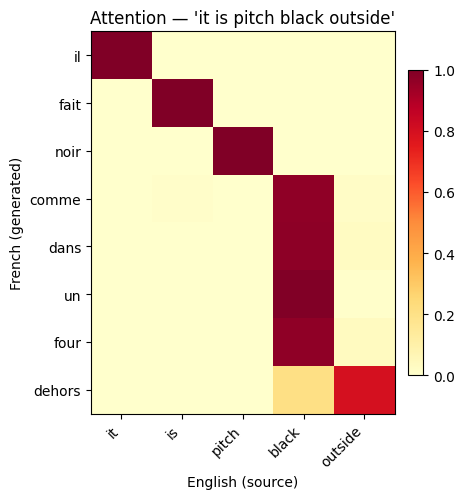

In [26]:
demo_sentence = test_df.sample(1, random_state=1).iloc[0]["English"]
pred, src_toks, tgt_toks, attn = translate_sentence(demo_sentence, return_attention=True)
print(f"EN : {demo_sentence}")
print(f"FR : {pred}")
plot_attention(src_toks, tgt_toks, attn, title=f"Attention — '{demo_sentence}'")


## 13. Try your own sentences

Type any short English sentence. Keep it close to everyday spoken English — that is what this corpus looks like.


In [27]:
your_sentences = [
    "Hi.",
    "Run!",
    "I love you.",
    "Where is the bathroom?",
    "I am not ready yet.",
    "Can you help me please?",
]

for s in your_sentences:
    print(f"{s:28s} →  {translate_sentence(s)}")


Hi.                          →  hé
Run!                         →  courez
I love you.                  →  je t aime
Where is the bathroom?       →  où est la salle de bain
I am not ready yet.          →  je ne suis pas encore prêt
Can you help me please?      →  peux tu m aider s il te plait


## 14. Save the model

You can reload `seq2seq_en_fr.pt` later without retraining. The checkpoint stores vocabularies as well, because IDs are meaningless without them.


In [28]:
ckpt_path = Path("seq2seq_en_fr.pt")
torch.save(
    {
        "model_state": model.state_dict(),
        "config": CONFIG,
        "src_word2idx": src_vocab.word2idx,
        "tgt_word2idx": tgt_vocab.word2idx,
    },
    ckpt_path,
)
print(f"Saved checkpoint → {ckpt_path.resolve()}")


Saved checkpoint → /kaggle/working/seq2seq_en_fr.pt


## 15. Workshop recap

| Piece | What it did |
|---|---|
| Cleaning | Normalized text so `Don't` and `do not` look the same |
| Vocabulary | Mapped words ↔ IDs, with `<pad> / <unk> / <start> / <end>` |
| Encoder (BiLSTM) | Read English forwards and backwards |
| Attention | Let each French word look at the relevant English words |
| Decoder (LSTM) | Wrote French one token at a time |
| Teacher forcing | Fed the true previous word during training |
| Greedy decode | Fed the model’s own previous word at test time |
| `ignore_index` | Stopped padding from inflating accuracy |

### Natural next steps (if you have extra time)
- **Beam search** instead of greedy decoding — keep the top-\(k\) hypotheses
- **Scheduled sampling** — mix gold tokens and model tokens during training
- **BLEU / chrF** — standard MT metrics (token accuracy is only a proxy)
- **Subword tokenization** (BPE / SentencePiece) — handles rare words better than a hard 8k vocab
- **Transformers** — replace LSTMs with self-attention (the modern default), You will now that topic in the next session.
